# 1 Connect to Qdrant

In [8]:
import json
import uuid
from pathlib import Path

from tqdm import tqdm

from qdrant_client import QdrantClient
from qdrant_client.models import (
    PointStruct,
    VectorParams,
    Distance,
)

from huggingface_hub import InferenceClient

from dotenv import load_dotenv
import os

Decide the Vector Size

Since we'll use Qwen/Qwen3-Embedding-0.6B, the embedding dimension is: VECTOR_SIZE = 1024

In [9]:
VECTOR_SIZE = 1024

### Create the Collection


In [10]:
from dotenv import load_dotenv
import os

load_dotenv()

QDRANT_URL = os.getenv("QDRANT_URL", "http://localhost:6333")

qdrant_client = QdrantClient(
    url=QDRANT_URL
)

print(qdrant_client.get_collections())

collections=[CollectionDescription(name='plant_diseases')]


In [11]:
from qdrant_client.models import VectorParams, Distance

COLLECTION_NAME = "plant_diseases"

existing = [c.name for c in qdrant_client.get_collections().collections]

if COLLECTION_NAME not in existing:

    qdrant_client.create_collection(
        collection_name=COLLECTION_NAME,
        vectors_config=VectorParams(
            size=1024,
            distance=Distance.COSINE
        )
    )

    print("Collection created!")

else:
    print("Collection already exists.")

Collection already exists.


# 2. Chunking 

In [12]:
import json
from pathlib import Path
from uuid import uuid4
from tqdm import tqdm

In [13]:
DISEASE_FOLDER = Path("../diseases") 

json_files = list(DISEASE_FOLDER.glob("*.json"))

print(f"Found {len(json_files)} disease files.")

Found 722 disease files.


### Chunk Generator

In [14]:
def create_chunks(disease):

    metadata = disease.get("metadata") or {}

    disease_name = metadata.get("title", "")
    crop = metadata.get("scientific_name", "")
    category = metadata.get("disease_category", "")

    common_metadata = {
        "disease_id": disease.get("id", ""),
        "title": disease_name,
        "crop": crop,
        "host_crops": metadata.get("host_crops", []),
        "category": category,
        "tags": disease.get("tags", []),
        "slug": metadata.get("slug", ""),
        "plantix_url": metadata.get("plantix_url", ""),
        "image_url": metadata.get("main_image_url", "")
    }

    chunks = []

    def add_chunk(section, content):

        if not content:
            return

        section_key = (
            section.lower()
            .replace(" ", "_")
            .replace("-", "_")
        )

        # Deterministic name
        chunk_name = f"{disease['id']}_{section_key}"

        # Deterministic UUID
        chunk_id = str(
            uuid.uuid5(
                uuid.NAMESPACE_DNS,
                chunk_name
            )
        )

        text = f"""
Disease: {disease_name}

Crop: {crop}

Category: {category}

Section: {section}

{content}
""".strip()

        chunks.append({
            "id": chunk_id,
            "text": text,
            "metadata": {
                **common_metadata,
                "section": section_key,
                "chunk_name": chunk_name
            }
        })

    overview = disease.get("overview") or {}
    add_chunk("Overview", overview.get("content", ""))

    symptoms = disease.get("symptoms") or {}
    add_chunk("Symptoms", symptoms.get("content", ""))

    causes = disease.get("causes") or {}
    add_chunk("Causes", causes.get("content", ""))

    recommendations = disease.get("recommendations") or {}

    organic = recommendations.get("organic") or {}
    add_chunk("Organic Control", organic.get("content", ""))

    chemical = recommendations.get("chemical") or {}
    add_chunk("Chemical Control", chemical.get("content", ""))

    preventive = disease.get("preventive_measures") or {}

    items = preventive.get("items", [])

    if items:
        add_chunk(
            "Preventive Measures",
            "\n".join(f"- {i}" for i in items)
        )

    environment = disease.get("environment") or {}

    env_lines = []

    for k, v in environment.items():
        if v is not None:
            env_lines.append(f"{k}: {v}")

    if env_lines:
        add_chunk(
            "Environment",
            "\n".join(env_lines)
        )

    return chunks

### Create All Chunks

In [15]:
all_chunks = []

for file in tqdm(json_files):

    with open(file, "r", encoding="utf-8") as f:
        disease = json.load(f)

    all_chunks.extend(create_chunks(disease))

print(f"Total disease files: {len(json_files)}")
print(f"Total chunks created: {len(all_chunks)}")

100%|██████████| 722/722 [00:00<00:00, 4723.66it/s]

Total disease files: 722
Total chunks created: 4860


### Inspect a Chunk

In [16]:
print(all_chunks[0]["text"])
print()
print(all_chunks[0]["metadata"])

Disease: Adventitious Roots

Crop: Tomato

Category: Pest

Section: Overview

Bumps on stems.

{'disease_id': 'adventitious_roots', 'title': 'Adventitious Roots', 'crop': 'Tomato', 'host_crops': ['tomato'], 'category': 'Pest', 'tags': ['pest', 'tomato', 'adventitious', 'roots'], 'slug': 'adventitious_roots', 'plantix_url': 'https://plantix.net/en/library/plant-diseases/800117/adventitious-roots/', 'image_url': 'https://content.peat-cloud.com/thumbnails/adventitious-roots-tomato-1716471629.jpg', 'section': 'overview', 'chunk_name': 'adventitious_roots_overview'}


# 3. Embedding

In [17]:
from huggingface_hub import InferenceClient
from tqdm import tqdm
import os

In [18]:
HF_TOKEN = os.getenv("HF_TOKEN")   

hf_client = InferenceClient(
    provider="hf-inference",
    api_key=HF_TOKEN
)

### choose model

In [19]:
EMBEDDING_MODEL = "BAAI/bge-m3"

test one embedding

In [20]:
text = all_chunks[0]["text"]

embedding = hf_client.feature_extraction(
    text,
    model=EMBEDDING_MODEL
)

print(len(embedding))

1024


create a helper function

In [21]:
def embed_text(text: str):

    return hf_client.feature_extraction(
        text,
        model=EMBEDDING_MODEL
    )

test again

In [22]:
vector = embed_text(all_chunks[0]["text"])

print(type(vector))
print(len(vector))

<class 'numpy.ndarray'>
1024


embed 1st 5 chunks

In [23]:
vectors = []

for chunk in all_chunks[:5]:

    vectors.append(
        embed_text(chunk["text"])
    )

print(len(vectors))

5


# 4. Upload Chunks to Qdrant

In [24]:
from qdrant_client.models import PointStruct
from tqdm import tqdm

In [25]:
# batch size
BATCH_SIZE = 64

upload function

In [26]:
def upload_batch(batch):

    texts = [c["text"] for c in batch]

    vectors = hf_client.feature_extraction(
        texts,
        model=EMBEDDING_MODEL
    )

    points = []

    for chunk, vector in zip(batch, vectors):

        points.append(

            PointStruct(

                id=chunk["id"],

                vector=vector,

                payload={
                    "text": chunk["text"],
                    **chunk["metadata"]
                }

            )

        )

    qdrant_client.upsert(

        collection_name="plant_diseases",

        points=points,

        wait=True

    )

Upload Everything

In [27]:
collection_info = qdrant_client.get_collection("plant_diseases")

uploaded = collection_info.points_count

print(f"Already uploaded: {uploaded}")

Already uploaded: 4860


In [28]:
from tqdm import tqdm

BATCH_SIZE = 32

collection_info = qdrant_client.get_collection("plant_diseases")
uploaded = collection_info.points_count

print(f"Resuming from chunk {uploaded}")

for i in tqdm(range(uploaded, len(all_chunks), BATCH_SIZE)):
    batch = all_chunks[i:i+BATCH_SIZE]
    upload_batch(batch)

print("✅ Upload completed!")

Resuming from chunk 4860


0it [00:00, ?it/s]

✅ Upload completed!


### verify upload

In [29]:
info = qdrant_client.get_collection("plant_diseases")

print("Points:", info.points_count)

Points: 4860


### 5. Verify the Database (Do this next)

In [30]:
query = "orange spots on apple leaves"

query_vector = embed_text(query)

results = qdrant_client.query_points(
    collection_name="plant_diseases",
    query=query_vector,
    limit=5
)

show results

In [32]:
for i, point in enumerate(results.points):

    print("="*80)
    print(f"Result {i+1}")
    print()

    print(point.payload["title"])
    print(point.payload["section"])
    print()

    print(point.payload["text"][:500])

Result 1

Marssonina Blotch of Apple
symptoms

Disease: Marssonina Blotch of Apple

Crop: Apple

Category: Fungus

Section: Symptoms

Late in the summer dark spots (5-10 mm) begin to appear on the upper surface of mature leaves. The symptoms are visible invariably after the rains in spring and in the early summer months. The leaves of older apple plants are more susceptible to the blotch than younger ones. The spots are usually grayish, brown with a tinge of purple at the tips. The disease symptoms appear in form of dark green circular patch
Result 2

Apple Scab
symptoms

Disease: Apple Scab

Crop: Apple

Category: Fungus

Section: Symptoms

The first visible symptoms of apple scab appear in the spring in the form of minute, circular, olive-green spots on leaves, often along a main vein. As they enlarge, they become brownish-black and eventually coalesce to form large patches of necrotic tissue. Affected leaves are often deformed and fall off prematurely, leading to defoliation in case

# 6. Build DiseaseRetriever

In [39]:
from typing import List
from qdrant_client import QdrantClient
from qdrant_client.models import (
    Filter,
    FieldCondition,
    MatchValue
)

retriever class

In [40]:
from typing import List, Optional

from qdrant_client.models import (
    Filter,
    FieldCondition,
    MatchValue,
)


class DiseaseRetriever:

    def __init__(
        self,
        qdrant_client,
        hf_client,
        embedding_model,
        collection_name="plant_diseases",
    ):

        self.qdrant = qdrant_client
        self.hf = hf_client
        self.model = embedding_model
        self.collection = collection_name

        # Order used when building context
        self.section_order = {
            "overview": 1,
            "symptoms": 2,
            "causes": 3,
            "organic_control": 4,
            "chemical_control": 5,
            "preventive_measures": 6,
            "environment": 7,
        }

    # --------------------------------------------------------
    # Embedding
    # --------------------------------------------------------

    def embed(self, text: str):

        return self.hf.feature_extraction(
            text,
            model=self.model,
        )

    # --------------------------------------------------------
    # Semantic Search
    # --------------------------------------------------------

    def search(
        self,
        query: str,
        limit: int = 5,
    ):

        vector = self.embed(query)

        results = self.qdrant.query_points(
            collection_name=self.collection,
            query=vector,
            limit=limit,
        )

        return results.points

    # --------------------------------------------------------
    # Retrieve Complete Disease
    # --------------------------------------------------------

    def get_disease(
        self,
        disease_id: str,
    ):

        points, _ = self.qdrant.scroll(

            collection_name=self.collection,

            scroll_filter=Filter(

                must=[

                    FieldCondition(
                        key="disease_id",
                        match=MatchValue(value=disease_id),
                    )

                ]

            ),

            limit=50,

        )

        points.sort(

            key=lambda p: self.section_order.get(
                p.payload.get("section", ""),
                999,
            )

        )

        return points

    # --------------------------------------------------------
    # Retrieve Single Section
    # --------------------------------------------------------

    def get_section(
        self,
        disease_id: str,
        section: str,
    ):

        section = (
            section.lower()
            .replace(" ", "_")
            .replace("-", "_")
        )

        points, _ = self.qdrant.scroll(

            collection_name=self.collection,

            scroll_filter=Filter(

                must=[

                    FieldCondition(
                        key="disease_id",
                        match=MatchValue(value=disease_id),
                    ),

                    FieldCondition(
                        key="section",
                        match=MatchValue(value=section),
                    ),

                ]

            ),

            limit=1,

        )

        if len(points) == 0:
            return None

        return points[0]

    # --------------------------------------------------------
    # Payload Only
    # --------------------------------------------------------

    def get_payloads(
        self,
        disease_id: str,
    ):

        return [

            point.payload

            for point in self.get_disease(disease_id)

        ]

    # --------------------------------------------------------
    # Build LLM Context
    # --------------------------------------------------------

    def build_context(
        self,
        disease_id: str,
        sections: Optional[List[str]] = None,
    ):

        chunks = self.get_disease(disease_id)

        if sections:

            sections = {

                s.lower()
                .replace(" ", "_")
                .replace("-", "_")

                for s in sections

            }

            chunks = [

                chunk

                for chunk in chunks

                if chunk.payload["section"] in sections

            ]

        return "\n\n".join(

            chunk.payload["text"]

            for chunk in chunks

        )

test

In [41]:
retriever = DiseaseRetriever(
    qdrant_client,
    hf_client,
    EMBEDDING_MODEL,
)

test 1

In [42]:
results = retriever.search(
    "orange spots on apple leaves"
)

for r in results:

    print(r.payload["title"])
    print(r.payload["section"])
    print(r.score)
    print()

Marssonina Blotch of Apple
symptoms
0.684055

Apple Scab
symptoms
0.6824993

Leaf Spot of Citrus
symptoms
0.65772384

Apple Scab
overview
0.6538283

Apple Chlorotic Leaf Spot Virus
symptoms
0.64980286



test 2

In [43]:
chunks = retriever.get_disease(
    "apple_scab"
)

for c in chunks:

    print(c.payload["section"])

overview
symptoms
causes
environment
organic control
preventive measures
chemical control


test 3

In [44]:
section = retriever.get_section(
    "apple_scab",
    "symptoms"
)

print(section.payload["text"])

Disease: Apple Scab

Crop: Apple

Category: Fungus

Section: Symptoms

The first visible symptoms of apple scab appear in the spring in the form of minute, circular, olive-green spots on leaves, often along a main vein. As they enlarge, they become brownish-black and eventually coalesce to form large patches of necrotic tissue. Affected leaves are often deformed and fall off prematurely, leading to defoliation in case of heavy infections. On shoots, the infections causes blistering and cracking that can then provide entry for opportunistic pathogens. On the fruits, brown to dark brown circular areas appear on the surface. As they develop further, they often coalesce and become raised, hard and corky. This restricts the expansion of the fruit and leads to distortion and cracking of the skin that expose the flesh. Light attacks do not affect the fruit quality significantly. However, the scabs can expose the fruits to opportunistic pathogens and rots, reducing the storage capacity and the

test 4

In [45]:
print(

    retriever.build_context(
        "apple_scab"
    )

)

Disease: Apple Scab

Crop: Apple

Category: Fungus

Section: Overview

Small, olive-green or brown spots on leaves.

Later form large brown patches.

Leaf deformation and premature fall off.

Dark brown, raised, hard areas on fruits.

Distortion and cracking of fruits.

Disease: Apple Scab

Crop: Apple

Category: Fungus

Section: Symptoms

The first visible symptoms of apple scab appear in the spring in the form of minute, circular, olive-green spots on leaves, often along a main vein. As they enlarge, they become brownish-black and eventually coalesce to form large patches of necrotic tissue. Affected leaves are often deformed and fall off prematurely, leading to defoliation in case of heavy infections. On shoots, the infections causes blistering and cracking that can then provide entry for opportunistic pathogens. On the fruits, brown to dark brown circular areas appear on the surface. As they develop further, they often coalesce and become raised, hard and corky. This restricts the 

test 5

In [46]:
print(

    retriever.build_context(

        "apple_scab",

        sections=[
            "symptoms",
            "causes",
        ]

    )

)

Disease: Apple Scab

Crop: Apple

Category: Fungus

Section: Symptoms

The first visible symptoms of apple scab appear in the spring in the form of minute, circular, olive-green spots on leaves, often along a main vein. As they enlarge, they become brownish-black and eventually coalesce to form large patches of necrotic tissue. Affected leaves are often deformed and fall off prematurely, leading to defoliation in case of heavy infections. On shoots, the infections causes blistering and cracking that can then provide entry for opportunistic pathogens. On the fruits, brown to dark brown circular areas appear on the surface. As they develop further, they often coalesce and become raised, hard and corky. This restricts the expansion of the fruit and leads to distortion and cracking of the skin that expose the flesh. Light attacks do not affect the fruit quality significantly. However, the scabs can expose the fruits to opportunistic pathogens and rots, reducing the storage capacity and the

# 7. Disease Mapper

mapper = DiseaseMapper()

mapper.normalize_prediction(
    "Apple___Cedar_apple_rust"
)

 Output
"cedar_apple_rust"

In [52]:
import re
import json
from pathlib import Path

mapper class

In [53]:
class DiseaseMapper:

    def __init__(self, disease_folder):

        self.lookup = {}

        self.alias_lookup = {}

        self.load_diseases(disease_folder)

    def load_diseases(self, disease_folder):

        disease_folder = Path(disease_folder)

        for file in disease_folder.glob("*.json"):

            with open(file, "r", encoding="utf-8") as f:
                disease = json.load(f)

            disease_id = disease["id"]

            metadata = disease["metadata"]

            title = metadata["title"]

            host_crops = metadata.get("host_crops", [])

            aliases = set()

            aliases.add(disease_id)

            aliases.add(title)

            aliases.add(title.lower())

            aliases.add(title.lower().replace(" ", "_"))

            aliases.add(title.lower().replace(" ", "-"))

            # CNN aliases
            for crop in host_crops:

                aliases.add(
                    f"{crop.title()}___{title.replace(' ', '_')}"
                )

                aliases.add(
                    f"{crop.capitalize()}___{disease_id}"
                )

            aliases = list(aliases)

            self.lookup[disease_id] = {

                "title": title,

                "aliases": aliases,

                "host_crops": host_crops

            }

            for alias in aliases:

                self.alias_lookup[
                    alias.lower()
                ] = disease_id

    def normalize(self, text):

        text = text.lower()

        text = text.replace(",", "")

        text = text.replace("(", "")

        text = text.replace(")", "")

        text = text.replace("-", "_")

        text = text.replace(" ", "_")

        text = re.sub("_+", "_", text)

        return text.strip("_")

    def map_prediction(self, prediction):

        if prediction.lower() in self.alias_lookup:

            disease_id = self.alias_lookup[
                prediction.lower()
            ]

        else:

            _, disease = prediction.split("___")

            disease_id = self.normalize(disease)

        crop = prediction.split("___")[0]

        crop = self.normalize(crop)

        return {

            "prediction": prediction,

            "crop": crop,

            "disease_id": disease_id,

            "title": self.lookup.get(
                disease_id,
                {}
            ).get("title")

        }

    def exists(self, disease_id):

        return disease_id in self.lookup

In [74]:
mapper = DiseaseMapper("../diseases")

test

In [75]:
mapper.map_prediction(
    "Apple___Cedar_apple_rust"
)

{'prediction': 'Apple___Cedar_apple_rust',
 'crop': 'apple',
 'disease_id': 'cedar_apple_rust',
 'title': None}

more test

In [79]:
cnn_classes = [
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___Cedar_apple_rust",
    "Apple___healthy",

    "Blueberry___healthy",

    "Cherry_(including_sour)___Powdery_mildew",
    "Cherry_(including_sour)___healthy",

    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn_(maize)___Common_rust_",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Corn_(maize)___healthy",

    "Grape___Black_rot",
    "Grape___Esca_(Black_Measles)",
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)",
    "Grape___healthy",

    "Orange___Haunglongbing_(Citrus_greening)",

    "Peach___Bacterial_spot",
    "Peach___healthy",

    "Pepper,_bell___Bacterial_spot",
    "Pepper,_bell___healthy",

    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",

    "Raspberry___healthy",

    "Soybean___healthy",

    "Squash___Powdery_mildew",

    "Strawberry___Leaf_scorch",
    "Strawberry___healthy",

    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Target_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___Tomato_mosaic_virus",
    "Tomato___healthy",
]

In [80]:
missing = []

for cls in cnn_classes:

    disease = mapper.map_prediction(cls)

    if disease["title"] is None:
        missing.append(cls)

print(f"Missing: {len(missing)}")

for m in missing:
    print(m)

Missing: 15
Apple___Cedar_apple_rust
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Pepper,_bell___Bacterial_spot
Potato___Late_blight
Strawberry___Leaf_scorch
Tomato___Bacterial_spot
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Tomato_mosaic_virus


In [81]:
print("apple_scab" in mapper.lookup)

True


In [82]:
print(list(mapper.lookup.keys())[:20])

['adventitious_roots', 'alfalfa_mosaic_virus', 'algal_leaf_spot', 'alkalinity', 'almond_bark_beetle', 'almond_red_leaf_blotch', 'alternaria_black_spot_and_fruit_rot', 'alternaria_brown_spot', 'alternaria_late_blight', 'alternaria_leaf_blight', 'alternaria_leaf_spot', 'alternaria_leaf_spot_of_cotton', 'alternaria_leaf_spot_peanut', 'alternaria_spot', 'american_gooseberry_mildew', 'angular_leaf_scorch', 'angular_leaf_spot', 'angular_leaf_spot_disease', 'angular_leaf_spot_of_strawberry', 'anthracnose']


In [83]:
print("Apple Scab" in mapper.lookup)
print("apple_scab" in mapper.lookup)

False
True


# 8. LLM integration

In [156]:
import os

from dotenv import load_dotenv

from langchain_google_genai import ChatGoogleGenerativeAI

from langchain_core.prompts import ChatPromptTemplate

from langchain_core.output_parsers import StrOutputParser

from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model

In [157]:
load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [158]:
# llm = ChatGoogleGenerativeAI(

#     model="gemini-3-flash-preview",

#     temperature=0,

#     google_api_key=GOOGLE_API_KEY,

#     convert_system_message_to_human=False

# )

llm=init_chat_model("groq:llama-3.3-70b-versatile")

In [159]:
class QuestionIntent(BaseModel):

    intents: list[str] = Field(

        description="""
One or more of:

overview
symptoms
causes
organic_control
chemical_control
preventive_measures
environment
general
"""

    )

In [160]:
response = llm.invoke("Hello!")

print(response.content)

Hello. How can I help you today?


Prompt Template

In [161]:
prompt = ChatPromptTemplate.from_messages(

    [

        (

            "system",

            """
You are an expert agricultural assistant.

Your job is to answer ONLY using the supplied context.

Rules:

1. Never invent facts.

2. If the answer is not present in the context,
say that the information is unavailable.

3. Do not mention the context.

4. Answer in Markdown.

5. Use headings.

6. Keep the answer concise but informative.

"""
        ),

        (

            "human",

            """
Disease Information

{context}

User Question

{question}
"""

        )

    ]

)

build chain

In [162]:
disease_chain = (

    prompt

    | llm

    | StrOutputParser()

)

Question Classifier Prompt

In [163]:
classifier_prompt = ChatPromptTemplate.from_messages(

    [

        (

            "system",

            """
You are an agricultural intent classifier.

Analyze the user's question.

Return one or more intents.

Allowed intents are

overview
symptoms
causes
organic_control
chemical_control
preventive_measures
environment
general

If multiple intents are relevant,
return all of them.

Never invent new intent names.
"""

        ),

        (

            "human",

            "{question}"

        )

    ]

)

classifier_chain = (

    classifier_prompt

    | llm.with_structured_output(
        QuestionIntent
    )

)

test with full context

In [164]:
context = retriever.build_context(
    "apple_scab"
)

answer = disease_chain.invoke(

    {

        "context": context,

        "question": "What are the symptoms?"

    }

)

print(answer)

### Symptoms of Apple Scab
The symptoms include:
* Small, olive-green or brown spots on leaves
* Large brown patches
* Leaf deformation and premature fall off
* Dark brown, raised, hard areas on fruits
* Distortion and cracking of fruits 

### Detailed Symptoms
* Minute, circular, olive-green spots on leaves, often along a main vein
* Blistering and cracking on shoots
* Brown to dark brown circular areas on the surface of fruits
* Coalescing and becoming raised, hard, and corky, leading to distortion and cracking of the skin.


test section retrival

In [165]:
context = retriever.build_context(
    "apple_scab",
    sections=["symptoms"]
)

answer = disease_chain.invoke(

    {

        "context": context,

        "question": "What are the symptoms?"

    }

)

print(answer)

### Symptoms of Apple Scab
The symptoms of apple scab include:
* Minute, circular, olive-green spots on leaves
* Brownish-black spots that coalesce to form large patches of necrotic tissue
* Deformed and premature falling of leaves
* Blistering and cracking on shoots
* Brown to dark brown circular areas on the fruit surface that become raised, hard, and corky
* Distortion and cracking of the fruit skin


test unknown questions

In [166]:
context = retriever.build_context("apple_scab")

answer = disease_chain.invoke(

    {

        "context": context,

        "question": "What fertilizer should I apply?"

    }

)

print(answer)

### Fertilizer Information
The information about the specific fertilizer to apply is unavailable. However, it is mentioned that 5% urea can be applied to leaves in the autumn to enhance their decomposition and obstruct the life cycle of the fungus. Additionally, applying lime after leaf drop can increase soil pH.


helper function
- Instead of repeatedly calling the chain, create a helper.

In [167]:
def ask_disease_llm(
    disease_id,
    question,
    sections=None,
):

    context = retriever.build_context(

        disease_id,

        sections=sections,

    )

    return disease_chain.invoke(

        {

            "context": context,

            "question": question,

        }

    )

In [168]:
print(

    ask_disease_llm(

        "apple_scab",

        "How can I prevent it?"

    )

)

### Preventive Measures
To prevent Apple Scab, consider the following:
* Use tolerant or resistant varieties
* Monitor orchards for signs of the disease
* Pick up affected leaves, shoots, and fruits
* Rake or mow fallen leaves to speed up decomposition
* Ensure good air circulation through pruning
* Avoid overhead irrigation and wetting foliage
* Apply lime after leaf drop to increase soil pH
* Spread mulch under trees, keeping it away from the trunk


# 9. Disease Agent (LangGraph)

In [176]:
from typing import TypedDict, Optional

from langgraph.graph import (
    StateGraph,
    START,
    END
)

from pydantic import BaseModel, Field

define state

In [177]:
from typing import TypedDict, Optional

class DiseaseState(TypedDict):

    prediction: str
    question: str

    disease_id: Optional[str]
    crop: Optional[str]

    intents: Optional[list[str]]

    context: Optional[str]

    response: Optional[str]

mapper node

In [178]:
def map_disease(state: DiseaseState):

    mapped = mapper.map_prediction(
        state["prediction"]
    )

    state["disease_id"] = mapped["disease_id"]

    state["crop"] = mapped["crop"]

    return state

In [179]:
def classify_question(state: DiseaseState):

    result = classifier_chain.invoke(

        {

            "question": state["question"]

        }

    )

    valid = {

        "overview",

        "symptoms",

        "causes",

        "organic_control",

        "chemical_control",

        "preventive_measures",

        "environment",

        "general",

    }

    intents = [

        i

        for i in result.intents

        if i in valid

    ]

    if len(intents) == 0:

        intents = ["general"]

    state["intents"] = intents

    return state

In [180]:
def retrieve_context(state: DiseaseState):

    disease = state["disease_id"]

    intents = state["intents"]

    if "general" in intents:

        context = retriever.build_context(
            disease
        )

    else:

        context = retriever.build_context(

            disease,

            sections=intents

        )

    state["context"] = context

    return state

LLM node

In [181]:
def generate_answer(state: DiseaseState):

    answer = disease_chain.invoke(

        {

            "context": state["context"],

            "question": state["question"]

        }

    )

    state["response"] = answer

    return state

build graph

In [182]:
builder = StateGraph(DiseaseState)

add nodes

In [183]:
builder.add_node(
    "mapper",
    map_disease
)

builder.add_node(
    "classifier",
    classify_question
)

builder.add_node(
    "retriever",
    retrieve_context
)

builder.add_node(
    "llm",
    generate_answer
)

add edges

In [184]:
builder.add_edge(
    START,
    "mapper"
)

builder.add_edge(
    "mapper",
    "classifier"
)

builder.add_edge(
    "classifier",
    "retriever"
)

builder.add_edge(
    "retriever",
    "llm"
)

builder.add_edge(
    "llm",
    END
)

compile

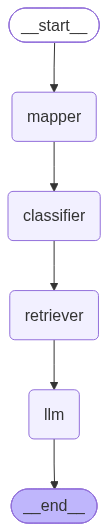

In [193]:
disease_agent = builder.compile()

## visualize the graph
from IPython.display import Image,display

try:
    display(Image(disease_agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)


test

In [194]:
result = disease_agent.invoke(

    {

        "prediction": "Apple___Apple_scab",

        "question": "What are the symptoms?"

    }

)

print(result["response"])

### Symptoms of Apple Scab
The symptoms include:
* Minute, circular, olive-green spots on leaves
* Brownish-black spots that coalesce to form large patches of necrotic tissue
* Deformed and premature falling of leaves
* Blistering and cracking of shoots
* Brown to dark brown circular areas on the fruit surface that become raised, hard, and corky
* Distortion and cracking of the fruit skin


more test

In [195]:
result = disease_agent.invoke(

    {

        "prediction": "Apple___Apple_scab",

        "question": "What are the symptoms?"

    }

)

print(result["response"])

### Symptoms of Apple Scab
The symptoms include:
* Minute, circular, olive-green spots on leaves
* Brownish-black spots that coalesce to form large patches of necrotic tissue
* Deformed and premature falling of leaves
* Blistering and cracking on shoots
* Brown to dark brown circular areas on the fruit surface that become raised, hard, and corky, leading to distortion and cracking of the skin.


In [196]:
result = disease_agent.invoke(

    {

        "prediction": "Apple___Apple_scab",

        "question": "What causes it?"

    }

)

print(result["response"])

### Cause of Apple Scab
The disease is caused by the fungus *Venturia inaequalis*.
